# Giai đoạn 8 — File CSV huấn luyện tổng hợp

```
┌───────────────────────────────────────────────────────────────────────────┐
│                               08_TrainFinal                               │
└───────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 03_TachTrainTest/khaosat_train.csv   —  574 phiếu thật
    • 06_GA_TangCuong/khung_ho_so.csv      —  2.613 hồ sơ nền
    • 06_GA_TangCuong/sinh_theo_fold.npz   —  Likert · giới tính · mục tiêu
    • 07_KiemDinhGA/ket_luan.json          —  bản GA nào thắng
         │
         ▼
  XỬ LÝ
    1. Ghép dòng thật và dòng tăng cường thành MỘT bảng duy nhất
    2. Dựng đủ 63 cột đặc trưng cho cả hai nguồn bằng CÙNG một hàm
    3. Thêm cột quản lý: nguồn · is_that · sample_weight
    4. Kiểm tra: không ô trống bất thường, nhãn hợp lệ, đủ 39 ngành
         │
         ▼
  ĐẦU RA
    • 08_TrainFinal/train_final.csv        ⭐  FILE HUẤN LUYỆN CHÍNH THỨC
    • 08_TrainFinal/thong_ke_dac_trung.csv
    • 08_TrainFinal/hinh_8_*.png           —  3 hình
```

## Đây là file bạn yêu cầu

Một bảng duy nhất, đã làm sạch và tiền xử lý xong, sẵn sàng đưa vào mô hình:

```
   574 dòng  phiếu khảo sát thật
+ 2.613 dòng  tăng cường (hồ sơ trúng tuyển thật + phần khảo sát do GA sinh)
────────────
 3.187 dòng × 70 cột  =  63 đặc trưng + 7 cột quản lý
```

## 63 đặc trưng đến từ 5 thứ học sinh khai

Không phải 63 thông tin khác nhau — chỉ là 5 thứ được bung ra thành các góc nhìn khác nhau:

```
10 câu Likert  ──┬──►  10 cột  likert_*        giữ nguyên
                 ├──►  10 cột  ips_likert_*    trừ trung bình của chính người đó
                 └──►   2 cột  likert_tb, likert_dolech

điểm 3 môn     ──┬──►  10 cột  diem_*          10 ô, chỉ 3 ô có số
                 ├──►  10 cột  z_diem_*        cùng điểm, đổi sang z-score
                 └──►   4 cột  diem_tb, diem_lech, z_tb, z_max

tổ hợp         ─────►  15 cột  th_*            one-hot, đúng 1 ô bằng 1

giới tính      ─────►   1 cột  gioi_tinh_nam
mục tiêu       ─────►   1 cột  muc_tieu
```

**`ips_likert_*` không phải bản sao thừa.** Có bạn chấm câu nào cũng 4–5, có bạn chấm câu nào cũng
2–3. Để số thô thì mô hình học nhầm "thói quen chấm điểm rộng rãi" thành "thích ngành này". Trừ đi
trung bình của chính bạn đó thì chỉ còn lại **bạn thích câu nào HƠN câu nào** — thứ ta cần.

**`z_diem_*` cũng vậy.** 8 điểm Toán và 8 điểm Văn không cùng ý nghĩa vì độ khó đề khác nhau;
z-score quy về "so với mặt bằng chung thì bạn này đứng đâu".

## Ô trống là bình thường, không phải dữ liệu hỏng

Mỗi học sinh chỉ thi **3 môn**, nên 7 trong 10 cột điểm chắc chắn trống. Đó là hình dạng của bài
toán. XGBoost học sẵn hướng rẽ cho ô trống ngay trong thuật toán, nên **không điền bừa** — điền bừa
tạo ra giá trị không có thật.

## Cột `sample_weight`

Mỗi dòng thật được đánh trọng số bằng bao nhiêu dòng tăng cường. Giai đoạn 9 sẽ dò giá trị tốt
nhất; ở đây để `1.0` cho mọi dòng, tức chưa ưu tiên bên nào.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True):
    """Đọc mọi thứ notebook huấn luyện cần.

    `co_test=True` CHỈ được bật ở Giai đoạn 10 — mở tập test đúng một lần.

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json. Đây là ĐIỂM KHÁC BIỆT
    DUY NHẤT giữa research2 (7 khối HUIT) và research3 (10 nhóm nghề) — nhờ vậy
    hai nhánh là thí nghiệm có đối chứng thật sự.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(3) / "khaosat_train.csv"),
        "folds": json.loads((thu_muc(3) / "cv_folds.json").read_text(encoding="utf-8")),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_test:
        d["test"] = pd.read_csv(thu_muc(3) / "khaosat_test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

OUT = thu_muc(8)

D = nap(co_ttth=True)
ks = D["train"]
L, C_DIEM = D["likert"], D["diem"]
NG = D["nganh"]

khung = pd.read_csv(thu_muc(6) / "khung_ho_so.csv")
Zs = np.load(thu_muc(6) / "sinh_theo_fold.npz")
KL = json.loads((thu_muc(7) / "ket_luan.json").read_text(encoding="utf-8"))
KEY = KL["key_thang"] + "_full"          # bản thắng, học từ toàn bộ train

print(f"Bản GA được Giai đoạn 7 chọn : {KL['ban_thang']}")
print(f"   AUC bộ phân biệt          : {KL['ban1_gauss' if 'gauss' in KEY else 'ban2_phieu_that']['auc']:.3f}")
print(f"   dùng khoá                 : {KEY}")
print(f"\nDòng thật     : {len(ks):,}")
print(f"Dòng tăng cường: {len(khung):,}")

Bản GA được Giai đoạn 7 chọn : Bản 1 — lấy mẫu Gauss
   AUC bộ phân biệt          : 0.550
   dùng khoá                 : likert_gauss_full

Dòng thật     : 574
Dòng tăng cường: 2,613


## 1. Dựng bảng tăng cường

In [2]:
tc = khung.copy()
for c, col in enumerate(L):
    tc[col] = Zs[KEY][:, c]
tc["gioi_tinh"] = np.where(Zs["gioi_tinh_full"] == 1, "Nam", "Nữ")
tc["muc_tieu_ma"] = Zs["muc_tieu_full"]

print(f"Bảng tăng cường: {len(tc):,} dòng")
print(f"   Likert  : {int(tc[L].values.min())}…{int(tc[L].values.max())}")
print(f"   Nam     : {(tc.gioi_tinh=='Nam').mean():.1%}"
      f"   (khảo sát thật {(ks.gioi_tinh=='Nam').mean():.1%})")
print(f"   Mục tiêu: {sorted(tc.muc_tieu_ma.unique())}")
assert tc[L].notna().all().all(), "còn ô Likert trống"
assert tc.gioi_tinh.notna().all(), "còn ô giới tính trống"

Bảng tăng cường: 2,613 dòng
   Likert  : 1…5
   Nam     : 42.4%   (khảo sát thật 43.7%)
   Mục tiêu: [1, 2, 3, 4]


## 2. Ghép thành một bảng

In [3]:
# Dùng CÙNG một hàm dựng đặc trưng cho cả hai nguồn — đây là điểm mấu chốt.
# Nếu mỗi nguồn dựng đặc trưng theo một cách, mô hình sẽ học được cách phân biệt
# "dòng này từ đâu ra" thay vì học về ngành học.
ks_ = ks.copy()
ks_["to_hop_thi"] = ks_.to_hop_thi.astype(str).str.split(" ").str[0]

F_ks = dac_trung(ks_, D)
F_tc = dac_trung(tc, D)
assert list(F_ks.columns) == list(F_tc.columns), "hai nguồn ra khác cột"
print(f"Đặc trưng: {F_ks.shape[1]} cột, giống nhau ở cả hai nguồn ✓\n")

QL = ["ma_nganh", "ma_nhom", "nganh_hoc", "to_hop_thi", "nguon", "is_that",
      "sample_weight"]

a = pd.concat([ks_[["ma_nganh"]].assign(
        ma_nhom=[D["nhom"][m] for m in ks_.ma_nganh],
        nganh_hoc=[D["ma_to_ten"][m] for m in ks_.ma_nganh],
        to_hop_thi=ks_.to_hop_thi.values, nguon="khaosat", is_that=1,
        sample_weight=1.0).reset_index(drop=True), F_ks], axis=1)

b = pd.concat([tc[["ma_nganh"]].assign(
        ma_nhom=[D["nhom"][m] for m in tc.ma_nganh],
        nganh_hoc=[D["ma_to_ten"][m] for m in tc.ma_nganh],
        to_hop_thi=tc.to_hop_thi.values, nguon=tc.nguon.values, is_that=0,
        sample_weight=1.0).reset_index(drop=True), F_tc], axis=1)

final = pd.concat([a[QL + list(F_ks.columns)], b[QL + list(F_tc.columns)]],
                  ignore_index=True)

print(f"train_final.csv: {len(final):,} dòng × {final.shape[1]} cột")
print(f"   {len(QL)} cột quản lý + {F_ks.shape[1]} cột đặc trưng\n")
print(final.nguon.value_counts().to_string())

# ── Kiểm tra ─────────────────────────────────────────────────────────────
assert len(final) == len(ks) + len(khung)
assert final.ma_nganh.nunique() == 39, "thiếu ngành"
assert final.is_that.eq(final.nguon.eq("khaosat")).all(), "is_that lệch với nguon"
assert final[L].notna().all().all(), "còn ô Likert trống"
assert (final[C_DIEM].notna().sum(axis=1) >= 3).all(), "có dòng dưới 3 môn điểm"
th_cols = [c for c in final.columns if c.startswith("th_")]
assert final[th_cols].sum(axis=1).eq(1).all(), "one-hot tổ hợp không đúng 1"
print("\n✓ mọi phép kiểm tra đạt")

Đặc trưng: 63 cột, giống nhau ở cả hai nguồn ✓

train_final.csv: 3,187 dòng × 70 cột
   7 cột quản lý + 63 cột đặc trưng

nguon
ttth                 2278
khaosat               574
bootstrap_khaosat     335

✓ mọi phép kiểm tra đạt


## 3. Thống kê đặc trưng

In [4]:
nhom_ct = nhom_dac_trung(list(F_ks.columns), D)
tk = []
for ten, cols in nhom_ct.items():
    if not cols:
        continue
    tk.append({
        "nhom_dac_trung": ten, "so_cot": len(cols),
        "o_trong_%": round(final[cols].isna().mean().mean() * 100, 1),
        "trong_khaosat_%": round(
            final.loc[final.is_that == 1, cols].isna().mean().mean() * 100, 1),
        "trong_tangcuong_%": round(
            final.loc[final.is_that == 0, cols].isna().mean().mean() * 100, 1),
    })
tk = pd.DataFrame(tk)
tk.to_csv(OUT / "thong_ke_dac_trung.csv", index=False)
print(tk.to_string(index=False))
print(f"\nTổng {tk.so_cot.sum()} cột đặc trưng")
print("\nÔ trống ở nhóm điểm là ĐÚNG: mỗi học sinh chỉ thi 3/10 môn.")
print("Các nhóm khác phải gần 0% — nếu không thì có lỗi ở bước ghép.")

             nhom_dac_trung  so_cot  o_trong_%  trong_khaosat_%  trong_tangcuong_%
                 Likert thô      10        0.0              0.0                0.0
Likert chuẩn hoá theo người      10        0.0              0.0                0.0
            Thống kê Likert       2        0.0              0.0                0.0
               Điểm thi thô      10       70.0             70.0               70.0
      Điểm z-score từng môn      10       70.0             70.0               70.0
          Phái sinh từ điểm       4        0.0              0.0                0.0
 Tổ hợp xét tuyển (one-hot)      15        0.0              0.0                0.0
   Nhân khẩu học & mục tiêu       2        0.0              0.0                0.0

Tổng 63 cột đặc trưng

Ô trống ở nhóm điểm là ĐÚNG: mỗi học sinh chỉ thi 3/10 môn.
Các nhóm khác phải gần 0% — nếu không thì có lỗi ở bước ghép.


   💾 hinh_8_1_cau_tao.png


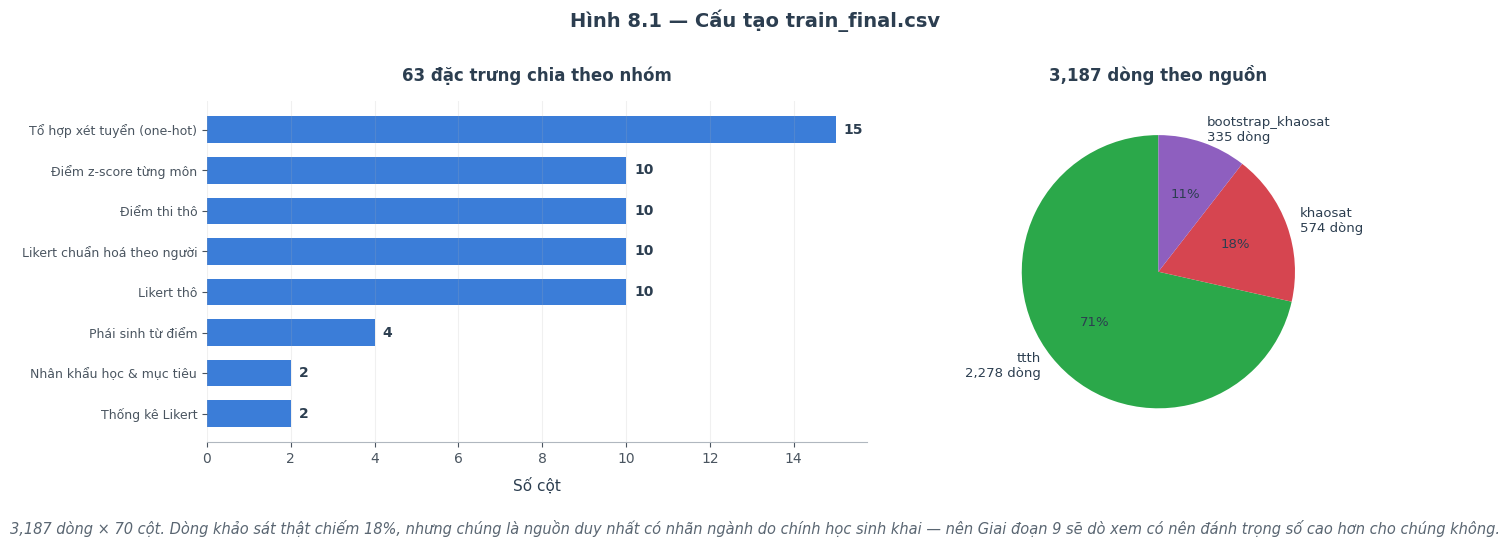

In [5]:
# ═══════════ HÌNH 8.1 — Cấu tạo bảng ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))
t = tk.sort_values("so_cot")
a1.barh(range(len(t)), t.so_cot, color=C_XANH, height=.66)
a1.set_yticks(range(len(t)))
a1.set_yticklabels([n[:32] for n in t.nhom_dac_trung], fontsize=9)
a1.set_xlabel("Số cột"); a1.set_title("63 đặc trưng chia theo nhóm", fontsize=12)
a1.grid(axis="y", alpha=0)
nhan_ngang(a1, t.so_cot, "{:.0f}")

ng_ = final.nguon.value_counts()
a2.pie(ng_.values, labels=[f"{k}\n{v:,} dòng" for k, v in ng_.items()],
       colors=[C_GA, C_THAT, C_TIM][:len(ng_)], autopct="%1.0f%%", startangle=90,
       textprops={"fontsize": 9.5})
a2.set_title(f"{len(final):,} dòng theo nguồn", fontsize=12)

fig.suptitle("Hình 8.1 — Cấu tạo train_final.csv", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_8_1_cau_tao.png",
    f"{len(final):,} dòng × {final.shape[1]} cột. Dòng khảo sát thật chiếm "
    f"{final.is_that.mean():.0%}, nhưng chúng là nguồn duy nhất có nhãn ngành do chính học sinh "
    "khai — nên Giai đoạn 9 sẽ dò xem có nên đánh trọng số cao hơn cho chúng không.")
plt.show()

   💾 hinh_8_2_o_trong.png


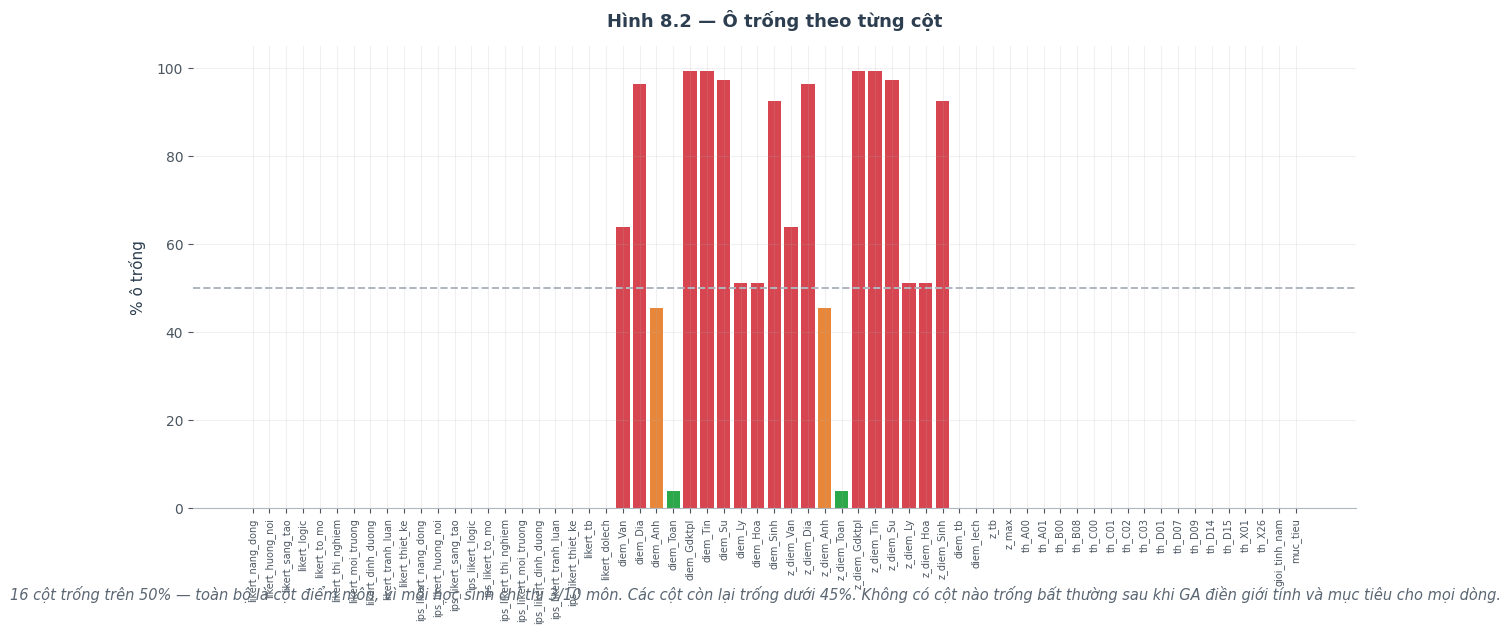

In [6]:
# ═══════════ HÌNH 8.2 — Ô trống ═══════════
fig, ax = plt.subplots(figsize=(15, 6))
tr_ = final[list(F_ks.columns)].isna().mean() * 100
mau = [C_THAT if v > 50 else (C_CAM if v > 5 else C_GA) for v in tr_]
ax.bar(range(len(tr_)), tr_.values, color=mau)
ax.set_xticks(range(len(tr_)))
ax.set_xticklabels(tr_.index, rotation=90, fontsize=7)
ax.set_ylabel("% ô trống"); ax.set_ylim(0, 105)
ax.set_title("Hình 8.2 — Ô trống theo từng cột")
ax.axhline(50, color=C_XAM, ls="--", lw=1.4)
n_cao = int((tr_ > 50).sum())
luu(fig, OUT, "hinh_8_2_o_trong.png",
    f"{n_cao} cột trống trên 50% — toàn bộ là cột điểm môn, vì mỗi học sinh chỉ thi 3/10 môn. "
    f"Các cột còn lại trống dưới {tr_[tr_ <= 50].max():.0f}%. Không có cột nào trống bất thường "
    "sau khi GA điền giới tính và mục tiêu cho mọi dòng.")
plt.show()

   💾 hinh_8_3_can_bang.png


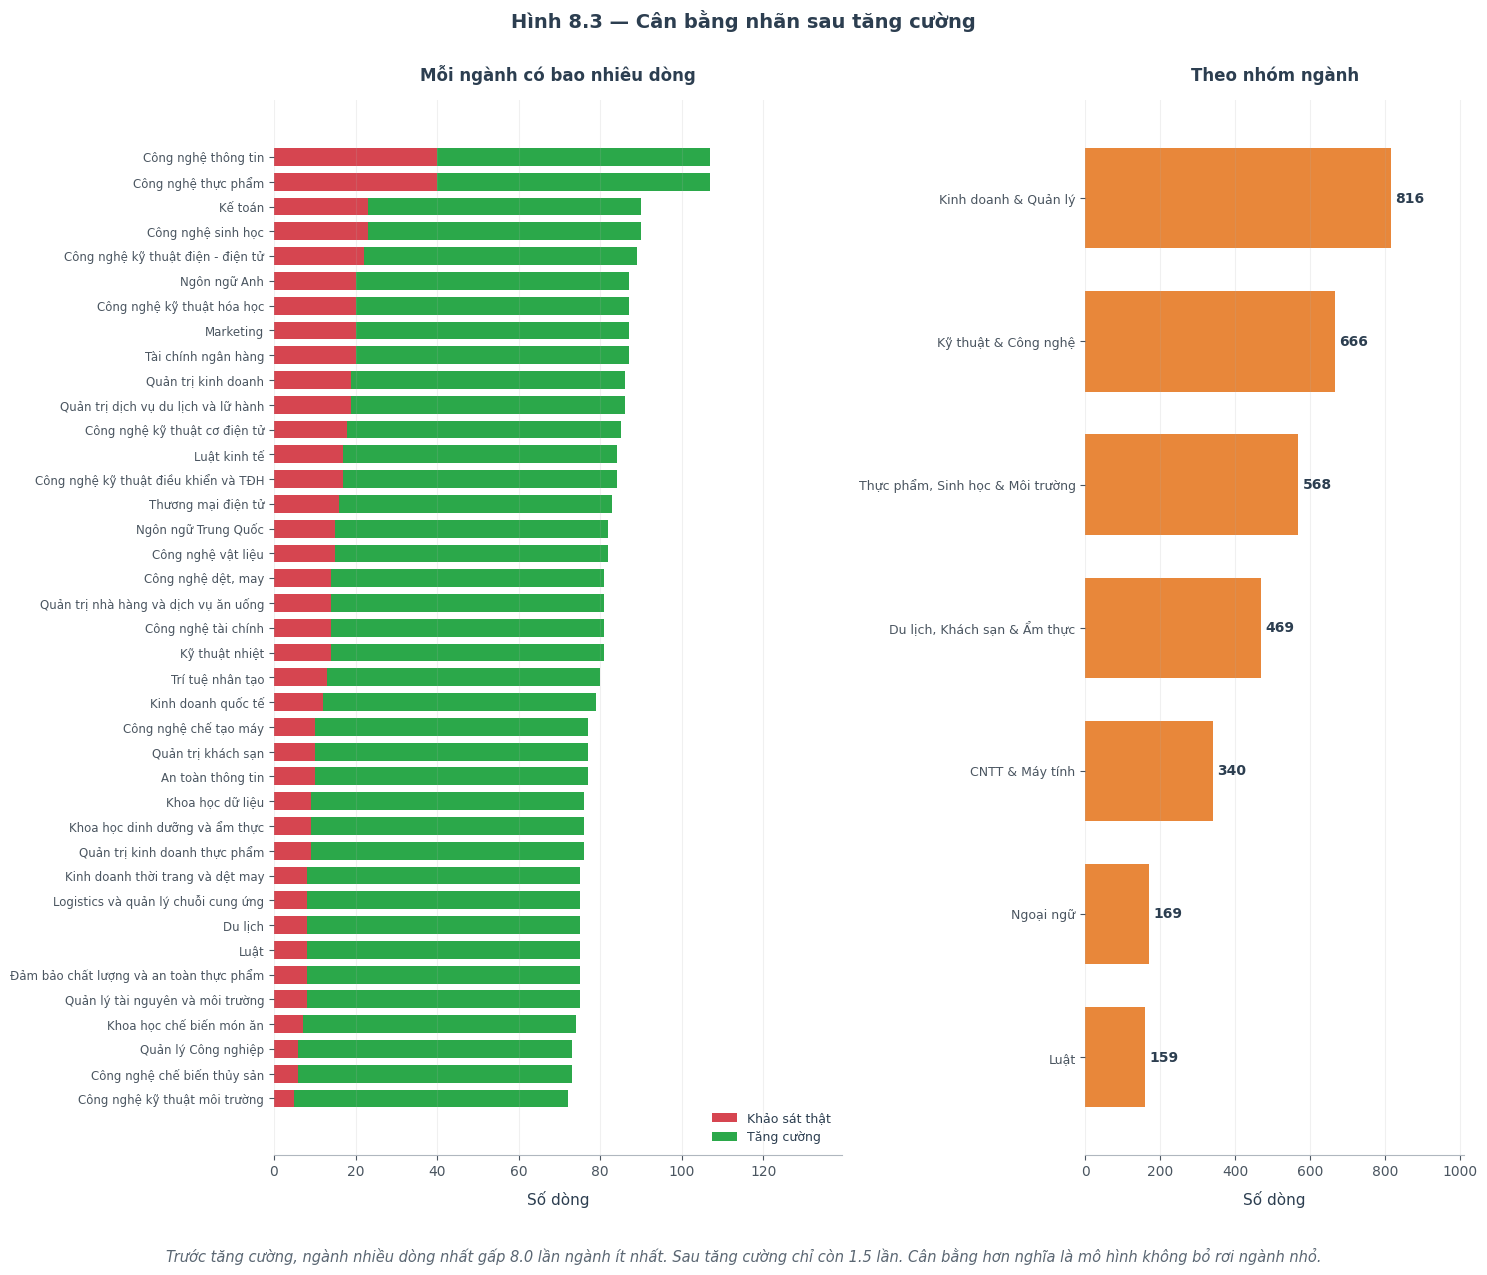

In [7]:
# ═══════════ HÌNH 8.3 — Cân bằng nhãn ═══════════
cn = final.groupby(["ma_nganh", "is_that"]).size().unstack(fill_value=0)
cn["ten"] = [D["ma_to_ten"][m] for m in cn.index]
cn = cn.sort_values(1)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, cao_theo_dong(len(cn))),
                             gridspec_kw={"width_ratios": [1.5, 1]})
yy = np.arange(len(cn))
a1.barh(yy, cn[1], color=C_THAT, height=.72, label="Khảo sát thật")
a1.barh(yy, cn[0], left=cn[1], color=C_GA, height=.72, label="Tăng cường")
a1.set_yticks(yy); a1.set_yticklabels(list(cn.ten), fontsize=8.5)
a1.set_xlabel("Số dòng"); a1.set_title("Mỗi ngành có bao nhiêu dòng", fontsize=12)
cho_chu_giai(a1, phan=.24)
a1.legend(loc="lower right", fontsize=9, framealpha=.95)
a1.grid(axis="y", alpha=0)

# Cột NGANG cho nhóm: tên nhóm dài, xoay chữ thì luôn chồng nhau
ck = final.ma_nhom.value_counts().sort_values()
a2.barh(range(len(ck)), ck.values, color=C_CAM, height=.7)
a2.set_yticks(range(len(ck)))
a2.set_yticklabels([D["ten_nhom"][i] for i in ck.index], fontsize=9)
a2.set_xlabel("Số dòng"); a2.set_title("Theo nhóm ngành", fontsize=12)
a2.grid(axis="y", alpha=0)
cho_chu_giai(a2, phan=.18)
nhan_ngang(a2, ck.values, "{:,.0f}")

fig.suptitle("Hình 8.3 — Cân bằng nhãn sau tăng cường",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
tong_ng = cn[0] + cn[1]
truoc = cn[1].max() / cn[1].min()
sau = tong_ng.max() / tong_ng.min()
luu(fig, OUT, "hinh_8_3_can_bang.png",
    f"Trước tăng cường, ngành nhiều dòng nhất gấp {truoc:.1f} lần ngành ít nhất. Sau tăng cường "
    f"chỉ còn {sau:.1f} lần. Cân bằng hơn nghĩa là mô hình không bỏ rơi ngành nhỏ.")
plt.show()

## 4. Xuất file

In [8]:
final.to_csv(OUT / "train_final.csv", index=False)
kb = (OUT / "train_final.csv").stat().st_size / 1e6

(OUT / "tom_tat.json").write_text(json.dumps({
    "n_dong": len(final), "n_cot": int(final.shape[1]),
    "n_dac_trung": int(F_ks.shape[1]), "n_cot_quan_ly": len(QL),
    "n_that": int(final.is_that.sum()),
    "n_tang_cuong": int((1 - final.is_that).sum()),
    "theo_nguon": final.nguon.value_counts().to_dict(),
    "ban_ga": KL["ban_thang"], "khoa_npz": KEY,
    "n_nganh": int(final.ma_nganh.nunique()),
    "n_nhom": int(final.ma_nhom.nunique()),
    "mb": round(kb, 1),
}, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 8 — FILE HUẤN LUYỆN TỔNG HỢP", [
    f"train_final.csv        {len(final):,} dòng × {final.shape[1]} cột"
    f"   ({kb:.1f} MB)",
    f"   {'✅ vượt mục tiêu 3.000 dòng' if len(final) > 3000 else '❌ chưa đủ 3.000'}",
    "",
    f"   khảo sát thật       {int(final.is_that.sum()):,}",
    f"   tăng cường          {int((1-final.is_that).sum()):,}"
    f"   (bản GA: {KL['ban_thang']})",
    "",
    f"Đặc trưng              {F_ks.shape[1]} cột",
] + [f"   {r.nhom_dac_trung:<32} {r.so_cot:>2} cột"
     f"   trống {r['o_trong_%']:>4.1f}%" for _, r in tk.iterrows()] + [
    "",
    f"Cột quản lý            {', '.join(QL)}",
    f"Nhãn                   {final.ma_nganh.nunique()} ngành"
    f" → {final.ma_nhom.nunique()} khối",
    f"Cân bằng ngành         chênh {sau:.1f} lần (trước tăng cường {truoc:.1f} lần)",
])
print(f"\n⭐ train_final.csv  →  {OUT}")
print(f"   Đây là file huấn luyện chính thức. Giai đoạn 9 và 10 đọc từ đây.")

╔════════════════════════════════════════════════════════════════════════════╗
║                   GIAI ĐOẠN 8 — FILE HUẤN LUYỆN TỔNG HỢP                   ║
╠════════════════════════════════════════════════════════════════════════════╣
║ train_final.csv        3,187 dòng × 70 cột   (1.5 MB)                      ║
║    ✅ vượt mục tiêu 3.000 dòng                                              ║
║                                                                            ║
║    khảo sát thật       574                                                 ║
║    tăng cường          2,613   (bản GA: Bản 1 — lấy mẫu Gauss)             ║
║                                                                            ║
║ Đặc trưng              63 cột                                              ║
║    Likert thô                       10 cột   trống  0.0%                   ║
║    Likert chuẩn hoá theo người      10 cột   trống  0.0%                   ║
║    Thống kê Likert                   2 cột   trống